# Stage 4: Exploratory Data Analysis (EDA)
## Heart Disease Prediction Using Patient Health Data

In this stage we visually and statistically explore the Cleveland dataset to uncover:
- Relationships between clinical features and the target variable
- Correlations between features (multicollinearity check)
- Distribution patterns and group differences
- Insights that will guide feature selection in Stage 5

---

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
import warnings
import os

warnings.filterwarnings('ignore')
os.makedirs('plots', exist_ok=True)

plt.rcParams['figure.dpi'] = 130
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False

PALETTE = ['#e74c3c', '#2ecc71']   # Red = No Disease, Green = Heart Disease
FEATURE_COLOR = '#3498db'

# Load data
df = pd.read_csv(r"C:\Users\Anagha\Downloads\Heart-disease-prediction\Heart-disease-prediction\heart-disease.csv")
print(f"Dataset loaded: {df.shape[0]} patients × {df.shape[1]} features")
print(f"Target distribution: {df['target'].value_counts().to_dict()}")

Dataset loaded: 303 patients × 14 features
Target distribution: {1: 165, 0: 138}


## 4.1 Target Variable Distribution

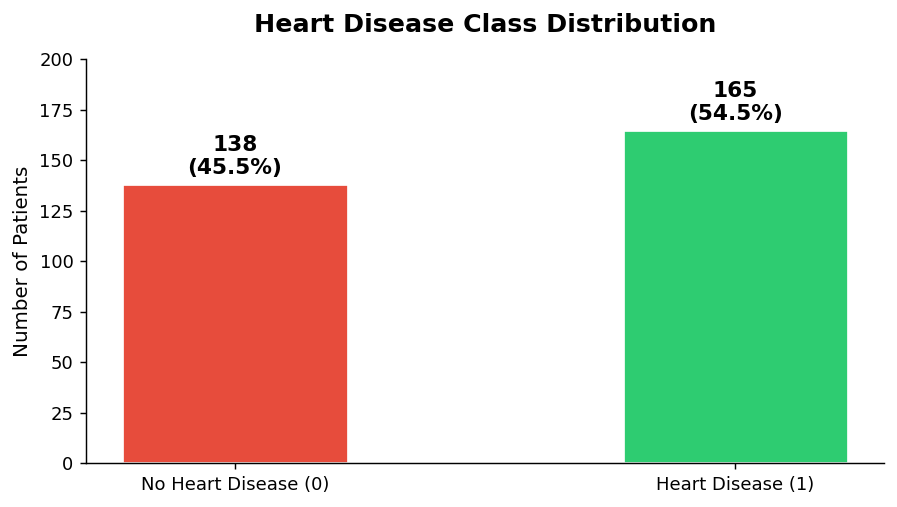


Observation:
  • 165 patients (54.5%) have heart disease — slight positive class majority.
  • 138 patients (45.5%) do not — mild class imbalance exists.
  • We will use stratified splits and report precision/recall, not just accuracy.


In [3]:
target_counts = df['target'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['No Heart Disease (0)', 'Heart Disease (1)'],
              target_counts.values, color=PALETTE, edgecolor='white', linewidth=1.5, width=0.45)

for bar, val in zip(bars, target_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 3,
            f'{val}\n({val/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_title('Heart Disease Class Distribution', fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Number of Patients', fontsize=11)
ax.set_ylim(0, max(target_counts.values) + 35)

plt.tight_layout()
plt.savefig('plots/target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nObservation:")
print("  • 165 patients (54.5%) have heart disease — slight positive class majority.")
print("  • 138 patients (45.5%) do not — mild class imbalance exists.")
print("  • We will use stratified splits and report precision/recall, not just accuracy.")

## 4.2 Age Distribution by Disease Status

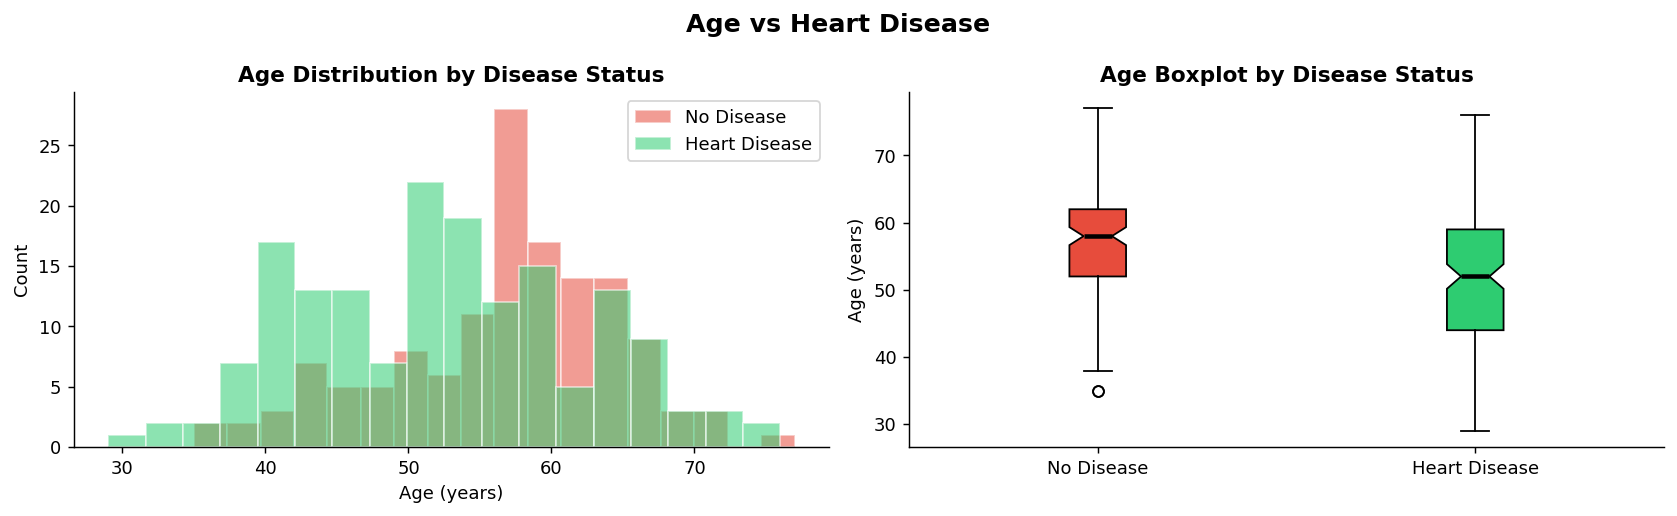

Mean age — Heart Disease: 52.5 | No Disease: 56.6
Independent t-test: t=-4.015, p=0.0001
Result: The age difference between groups is statistically significant (p < 0.05).


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram with KDE
for cls, color, label in zip([0, 1], PALETTE, ['No Disease', 'Heart Disease']):
    subset = df[df['target'] == cls]['age']
    axes[0].hist(subset, bins=18, alpha=0.55, color=color, label=label, edgecolor='white')

axes[0].set_title('Age Distribution by Disease Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
disease_labels = df['target'].map({0: 'No Disease', 1: 'Heart Disease'})
bp = axes[1].boxplot(
    [df[df['target']==0]['age'], df[df['target']==1]['age']],
    labels=['No Disease', 'Heart Disease'],
    patch_artist=True,
    notch=True,
    boxprops=dict(facecolor='lightgrey'),
    medianprops=dict(color='black', linewidth=2.5)
)
bp['boxes'][0].set_facecolor(PALETTE[0])
bp['boxes'][1].set_facecolor(PALETTE[1])
axes[1].set_title('Age Boxplot by Disease Status', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Age (years)')

plt.suptitle('Age vs Heart Disease', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/age_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistical test
age_disease   = df[df['target']==1]['age']
age_nodisease = df[df['target']==0]['age']
t_stat, p_val = stats.ttest_ind(age_disease, age_nodisease)
print(f"Mean age — Heart Disease: {age_disease.mean():.1f} | No Disease: {age_nodisease.mean():.1f}")
print(f"Independent t-test: t={t_stat:.3f}, p={p_val:.4f}")
significance = 'statistically significant (p < 0.05)' if p_val < 0.05 else 'not statistically significant'
print(f"Result: The age difference between groups is {significance}.")

## 4.3 Correlation Heatmap

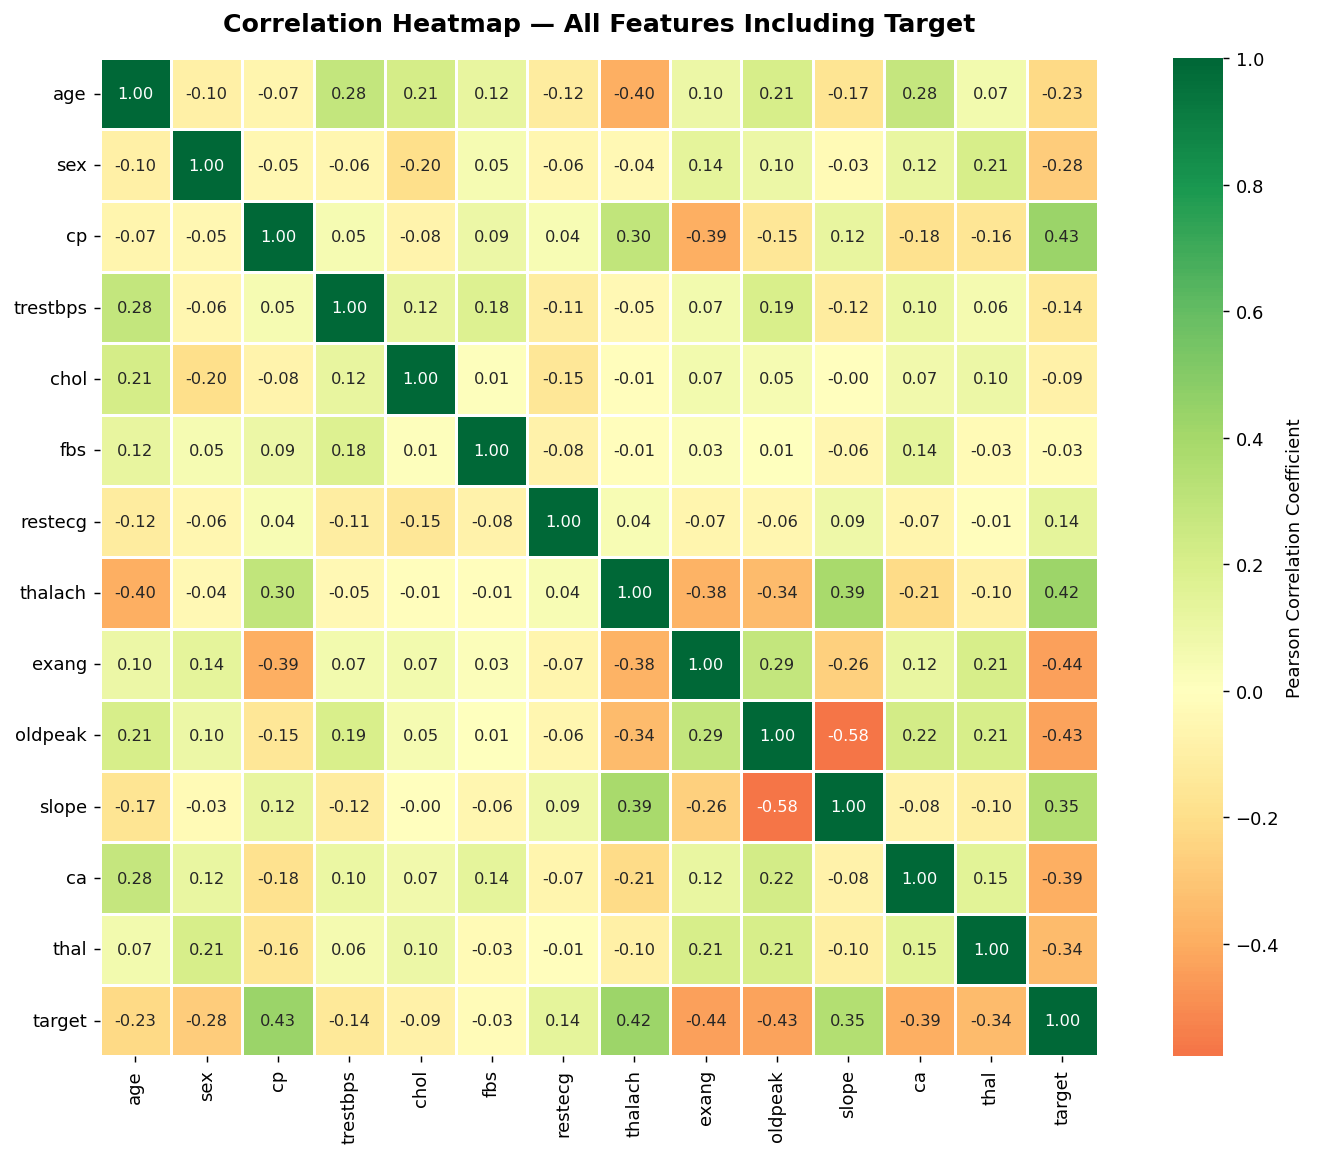

TOP FEATURE CORRELATIONS WITH TARGET:
  exang         r = -0.437  (-) Negative
  cp            r = +0.434  (+) Positive
  oldpeak       r = -0.431  (-) Negative
  thalach       r = +0.422  (+) Positive
  ca            r = -0.392  (-) Negative
  slope         r = +0.346  (+) Positive
  thal          r = -0.344  (-) Negative
  sex           r = -0.281  (-) Negative
  age           r = -0.225  (-) Negative
  trestbps      r = -0.145  (-) Negative
  restecg       r = +0.137  (+) Positive
  chol          r = -0.085  (-) Negative
  fbs           r = -0.028  (-) Negative

Key Findings:
  • cp (chest pain type) has the strongest positive correlation with heart disease.
  • exang (exercise angina) and oldpeak also positively correlate.
  • thalach (max heart rate) has a strong negative correlation — lower HR = more risk.


In [5]:
corr_matrix = df.corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # only lower triangle

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    linewidths=0.6,
    square=True,
    annot_kws={'size': 9},
    cbar_kws={'label': 'Pearson Correlation Coefficient'}
)

plt.title('Correlation Heatmap — All Features Including Target', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('plots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Top correlations with target
target_corr = corr_matrix['target'].drop('target').sort_values(key=abs, ascending=False)
print("TOP FEATURE CORRELATIONS WITH TARGET:")
print("=" * 45)
for feat, val in target_corr.items():
    direction = '(+) Positive' if val > 0 else '(-) Negative'
    print(f"  {feat:<12}  r = {val:+.3f}  {direction}")
print()
print("Key Findings:")
print("  • cp (chest pain type) has the strongest positive correlation with heart disease.")
print("  • exang (exercise angina) and oldpeak also positively correlate.")
print("  • thalach (max heart rate) has a strong negative correlation — lower HR = more risk.")

## 4.4 Boxplots — Key Numerical Features vs Target

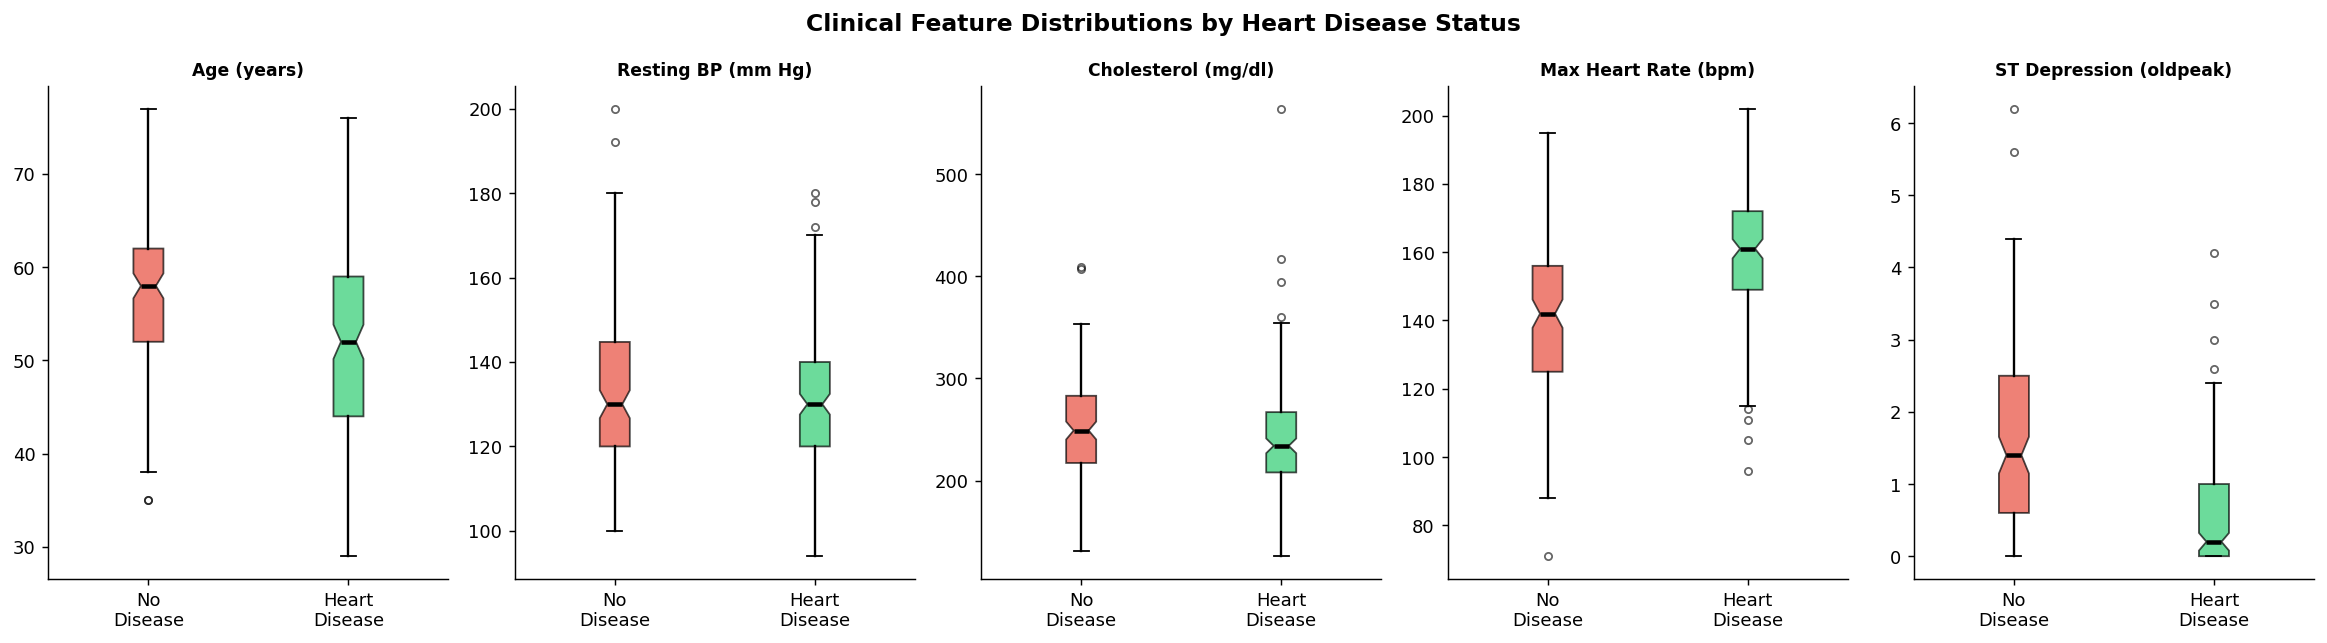

Key Observations:
  • thalach: Disease patients have LOWER max heart rate (71–202 bpm range).
  • oldpeak: Disease patients show higher ST depression values.
  • chol: Wide spread in both groups — cholesterol alone is not strongly predictive.
  • age: Disease group skews slightly older, but significant overlap exists.


In [6]:
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
feature_titles = ['Age (years)', 'Resting BP (mm Hg)', 'Cholesterol (mg/dl)',
                  'Max Heart Rate (bpm)', 'ST Depression (oldpeak)']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for ax, col, title in zip(axes, numerical_features, feature_titles):
    data_groups = [df[df['target']==0][col], df[df['target']==1][col]]
    bp = ax.boxplot(data_groups,
                    labels=['No\nDisease', 'Heart\nDisease'],
                    patch_artist=True,
                    notch=True,
                    medianprops=dict(color='black', linewidth=2.5),
                    whiskerprops=dict(linewidth=1.3),
                    flierprops=dict(marker='o', markersize=4, alpha=0.6))
    bp['boxes'][0].set_facecolor(PALETTE[0])
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor(PALETTE[1])
    bp['boxes'][1].set_alpha(0.7)
    ax.set_title(title, fontsize=9.5, fontweight='bold')

plt.suptitle('Clinical Feature Distributions by Heart Disease Status', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key Observations:")
print("  • thalach: Disease patients have LOWER max heart rate (71–202 bpm range).")
print("  • oldpeak: Disease patients show higher ST depression values.")
print("  • chol: Wide spread in both groups — cholesterol alone is not strongly predictive.")
print("  • age: Disease group skews slightly older, but significant overlap exists.")

## 4.5 Categorical Feature Analysis — Disease Rate per Category

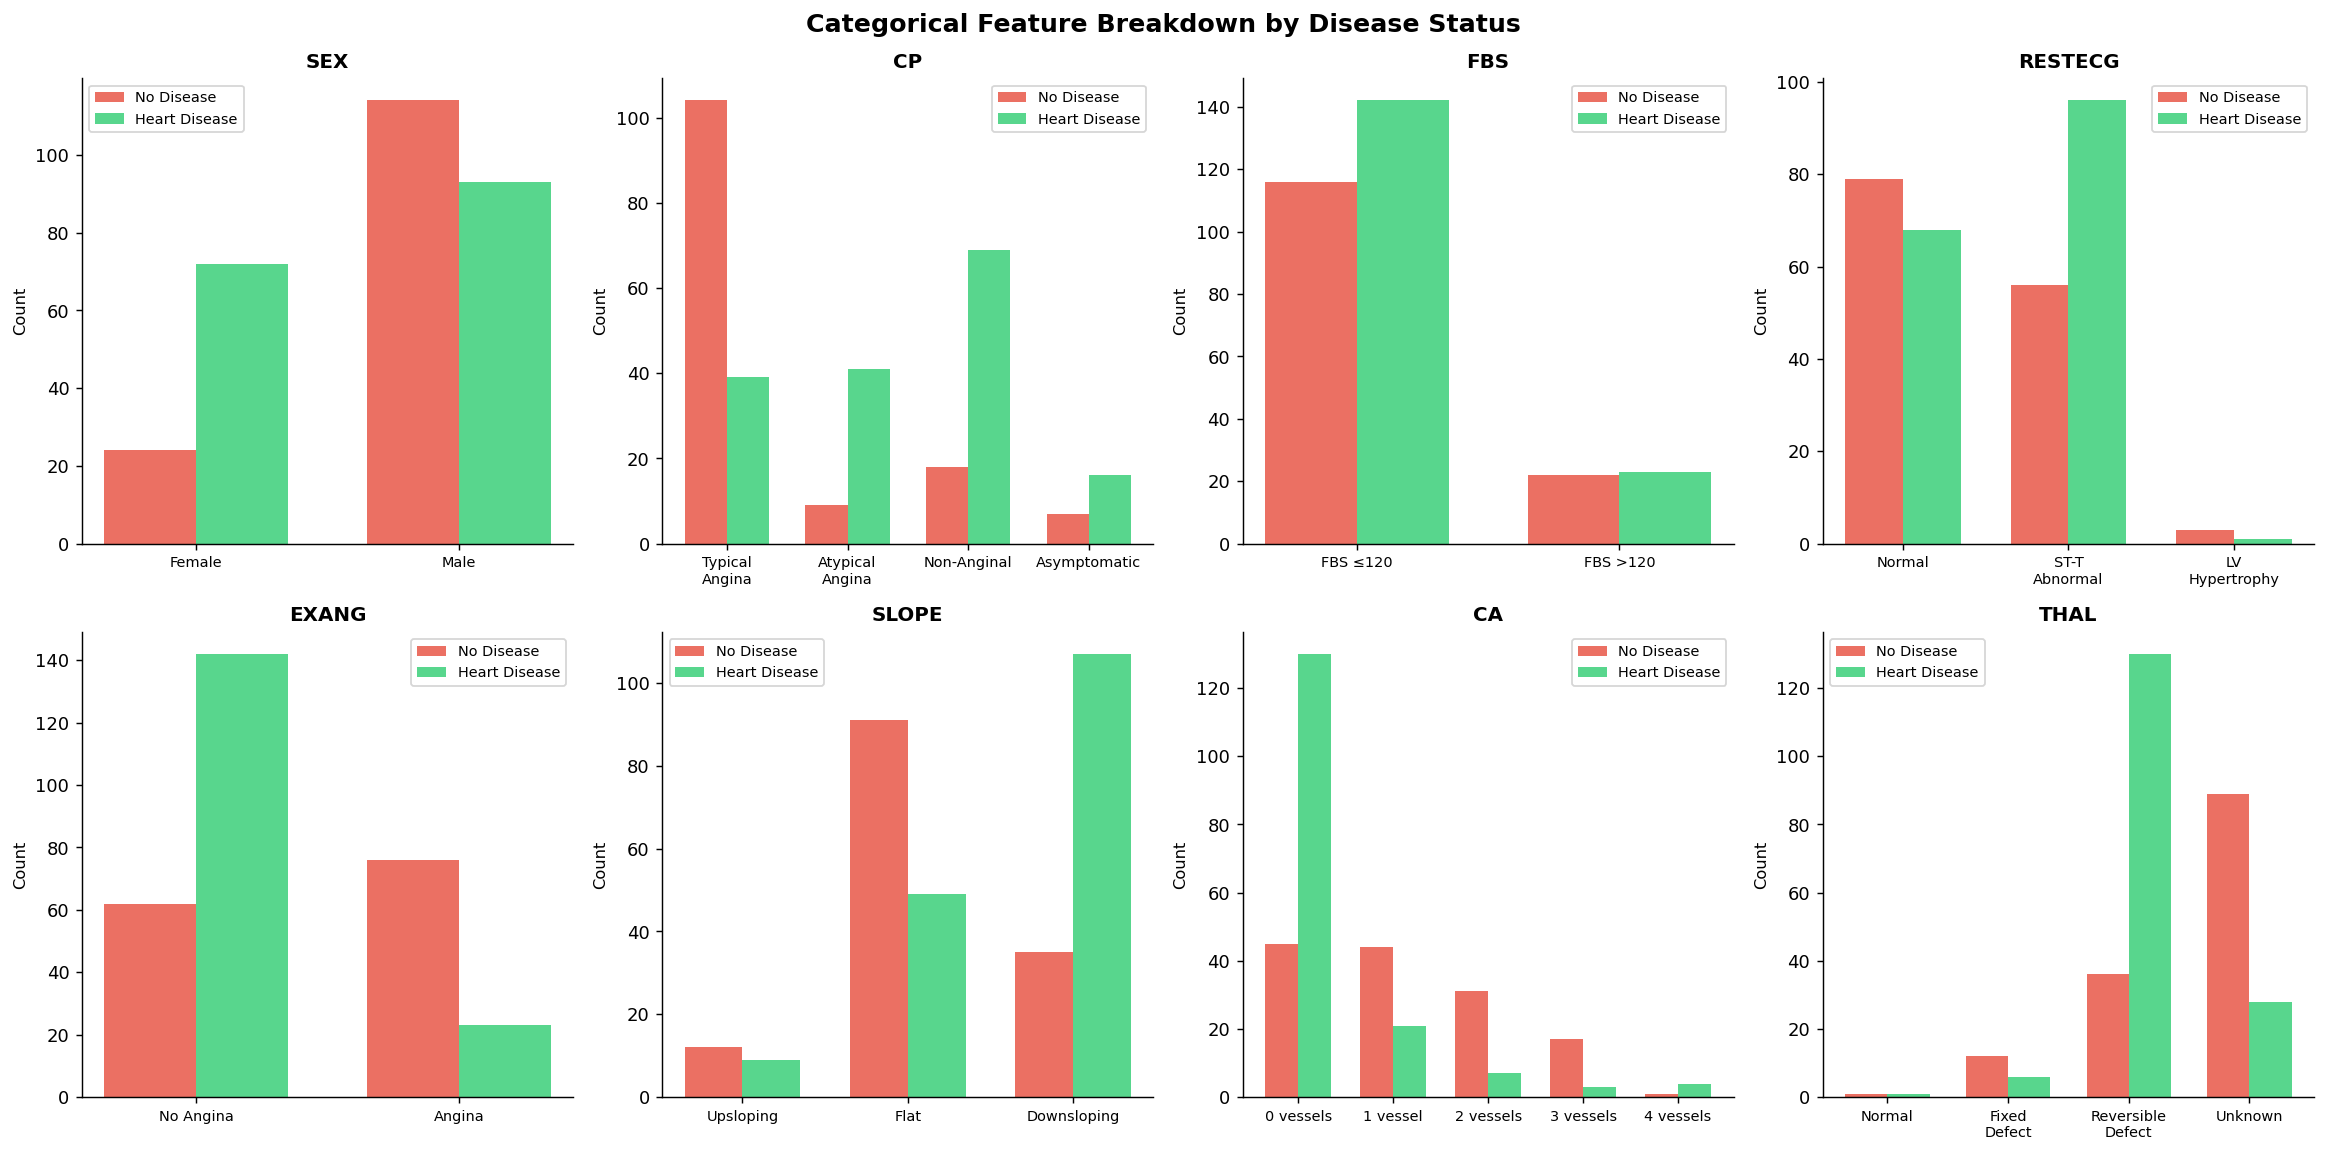

Key Observations:
  • cp=3 (Asymptomatic): Highest heart disease count — paradoxical but common in severe CAD.
  • exang=1 (Exercise Angina): Strong indicator of disease presence.
  • ca=0: Majority of disease patients have 0 major vessels coloured (early-stage).
  • thal=2 (Reversible Defect): Strongly associated with heart disease.


In [7]:
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

cat_labels = {
    'sex':     {0: 'Female', 1: 'Male'},
    'cp':      {0: 'Typical\nAngina', 1: 'Atypical\nAngina', 2: 'Non-Anginal', 3: 'Asymptomatic'},
    'fbs':     {0: 'FBS ≤120', 1: 'FBS >120'},
    'restecg': {0: 'Normal', 1: 'ST-T\nAbnormal', 2: 'LV\nHypertrophy'},
    'exang':   {0: 'No Angina', 1: 'Angina'},
    'slope':   {0: 'Upsloping', 1: 'Flat', 2: 'Downsloping'},
    'ca':      {0: '0 vessels', 1: '1 vessel', 2: '2 vessels', 3: '3 vessels', 4: '4 vessels'},
    'thal':    {0: 'Normal', 1: 'Fixed\nDefect', 2: 'Reversible\nDefect', 3: 'Unknown'}
}

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    ax = axes[i]
    grouped = df.groupby(col)['target'].value_counts(normalize=False).unstack(fill_value=0)
    grouped.columns = ['No Disease', 'Heart Disease']

    x = range(len(grouped))
    width = 0.35
    ax.bar([xi - width/2 for xi in x], grouped['No Disease'],   width, color=PALETTE[0], alpha=0.8, label='No Disease')
    ax.bar([xi + width/2 for xi in x], grouped['Heart Disease'], width, color=PALETTE[1], alpha=0.8, label='Heart Disease')

    labels = [cat_labels[col].get(idx, str(idx)) for idx in grouped.index]
    ax.set_xticks(list(x))
    ax.set_xticklabels(labels, fontsize=8)
    ax.set_title(f'{col.upper()}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Count', fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle('Categorical Feature Breakdown by Disease Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/categorical_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Key Observations:")
print("  • cp=3 (Asymptomatic): Highest heart disease count — paradoxical but common in severe CAD.")
print("  • exang=1 (Exercise Angina): Strong indicator of disease presence.")
print("  • ca=0: Majority of disease patients have 0 major vessels coloured (early-stage).")
print("  • thal=2 (Reversible Defect): Strongly associated with heart disease.")

## 4.6 Pair Plot — Key Features

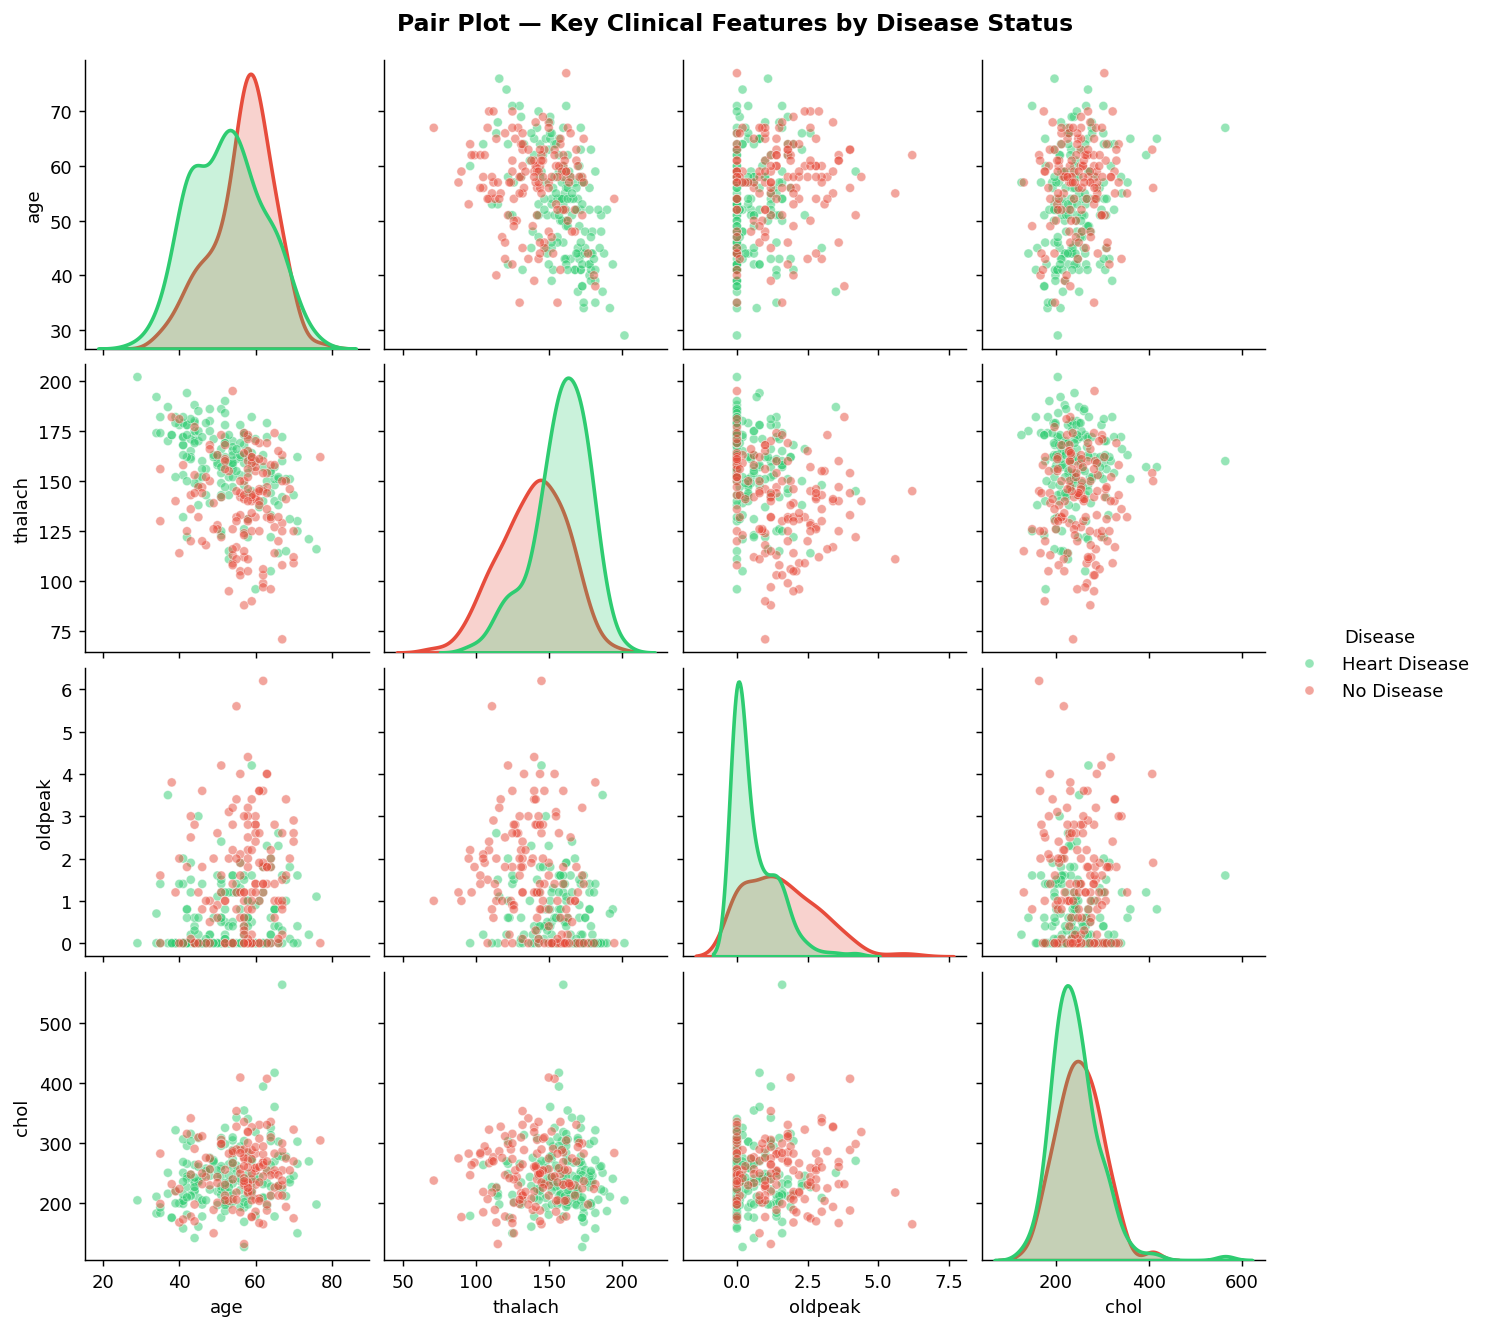

Saved to plots/pairplot.png

Observation: thalach vs oldpeak shows the clearest class separation.


In [8]:
# Select top features for pair plot
pair_features = ['age', 'thalach', 'oldpeak', 'chol', 'target']
pair_df = df[pair_features].copy()
pair_df['Disease'] = pair_df['target'].map({0: 'No Disease', 1: 'Heart Disease'})

g = sns.pairplot(
    pair_df.drop(columns='target'),
    hue='Disease',
    palette={'No Disease': PALETTE[0], 'Heart Disease': PALETTE[1]},
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 25},
    diag_kws={'linewidth': 2}
)
g.fig.suptitle('Pair Plot — Key Clinical Features by Disease Status', y=1.02, fontsize=13, fontweight='bold')
plt.savefig('plots/pairplot.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved to plots/pairplot.png")
print("\nObservation: thalach vs oldpeak shows the clearest class separation.")

## 4.7 Statistical Significance Tests (Mann-Whitney U)

In [9]:
from scipy.stats import mannwhitneyu

print("MANN-WHITNEY U TEST — NUMERICAL FEATURES")
print("(Non-parametric test: does not assume normal distribution)")
print("=" * 70)
print(f"{'Feature':<12} {'Disease Mean':>14} {'No Disease Mean':>16} {'U-Statistic':>13} {'p-value':>10} {'Significant?':>13}")
print("-" * 70)

numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
results = []

for col in numerical_cols:
    group_disease   = df[df['target'] == 1][col]
    group_nodisease = df[df['target'] == 0][col]
    u_stat, p_val = mannwhitneyu(group_disease, group_nodisease, alternative='two-sided')
    sig = '✅ Yes (p<0.05)' if p_val < 0.05 else '❌ No'
    results.append((col, group_disease.mean(), group_nodisease.mean(), u_stat, p_val, sig))
    print(f"  {col:<10}   {group_disease.mean():>12.2f}   {group_nodisease.mean():>14.2f}   {u_stat:>11.0f}   {p_val:>9.4f}   {sig}")

print()
print("Summary: thalach and oldpeak show the most statistically significant differences.")
print("cholesterol is NOT statistically significant — contradicts the popular assumption.")

MANN-WHITNEY U TEST — NUMERICAL FEATURES
(Non-parametric test: does not assume normal distribution)
Feature        Disease Mean  No Disease Mean   U-Statistic    p-value  Significant?
----------------------------------------------------------------------
  age                 52.50            56.60          8240      0.0000   ✅ Yes (p<0.05)
  trestbps           129.30           134.40          9784      0.0347   ✅ Yes (p<0.05)
  chol               242.23           251.09          9790      0.0357   ✅ Yes (p<0.05)
  thalach            158.47           139.10         17038      0.0000   ✅ Yes (p<0.05)
  oldpeak              0.58             1.59          5922      0.0000   ✅ Yes (p<0.05)

Summary: thalach and oldpeak show the most statistically significant differences.
cholesterol is NOT statistically significant — contradicts the popular assumption.


## 4.8 Chest Pain Type Deep Dive

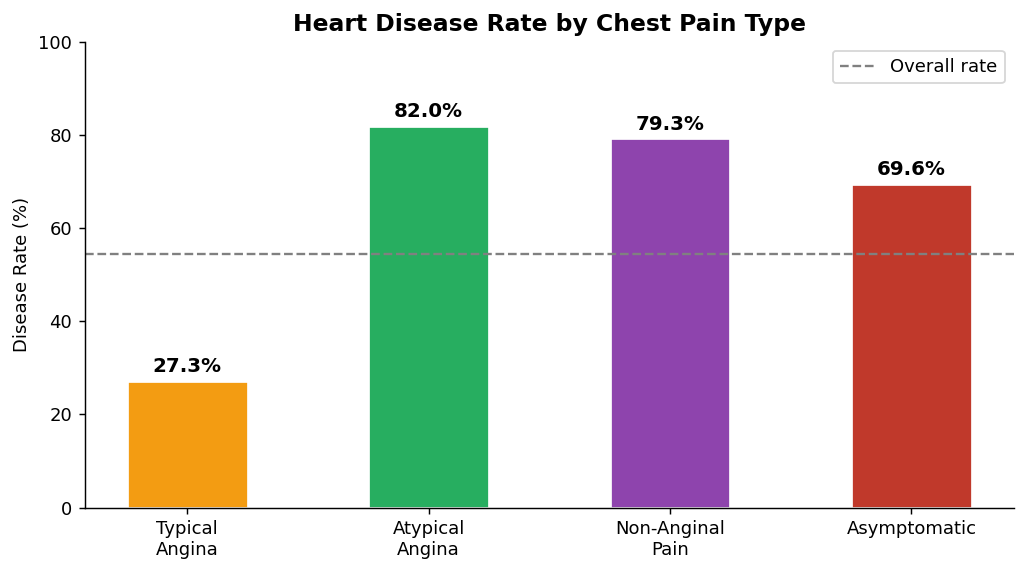

Finding:
  • Asymptomatic patients (cp=3) have the HIGHEST disease rate — clinically important.
  • This is known as 'silent ischemia' — no pain despite significant blockage.
  • Typical angina (cp=0) actually has a lower disease rate in this dataset.


In [10]:
cp_labels = {0: 'Typical\nAngina', 1: 'Atypical\nAngina', 2: 'Non-Anginal\nPain', 3: 'Asymptomatic'}

cp_disease_rate = df.groupby('cp')['target'].mean() * 100
cp_disease_rate.index = [cp_labels[i] for i in cp_disease_rate.index]

fig, ax = plt.subplots(figsize=(8, 4.5))
colors_bar = ['#f39c12', '#27ae60', '#8e44ad', '#c0392b']
bars = ax.bar(cp_disease_rate.index, cp_disease_rate.values,
              color=colors_bar, edgecolor='white', linewidth=1.5, width=0.5)

for bar, val in zip(bars, cp_disease_rate.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 1,
            f'{val:.1f}%',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Heart Disease Rate by Chest Pain Type', fontsize=13, fontweight='bold')
ax.set_ylabel('Disease Rate (%)')
ax.set_ylim(0, 100)
ax.axhline(df['target'].mean()*100, color='grey', linestyle='--', linewidth=1.3, label='Overall rate')
ax.legend()

plt.tight_layout()
plt.savefig('plots/chest_pain_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Finding:")
print("  • Asymptomatic patients (cp=3) have the HIGHEST disease rate — clinically important.")
print("  • This is known as 'silent ischemia' — no pain despite significant blockage.")
print("  • Typical angina (cp=0) actually has a lower disease rate in this dataset.")

## 4.9 EDA Summary & Key Insights

| # | Insight | Clinical Relevance |
|---|---|---|
| 1 | `cp` (chest pain type) has the strongest correlation with target (+0.43) | Asymptomatic presentation is paradoxically high-risk |
| 2 | `thalach` (max heart rate) negatively correlates with disease (−0.42) | Lower exercise capacity → higher disease risk |
| 3 | `exang` (exercise angina) strongly separates the classes | Classic clinical diagnostic criterion |
| 4 | `oldpeak` (ST depression) is higher in disease patients | Indicates myocardial ischemia under stress |
| 5 | `chol` (cholesterol) does NOT significantly separate classes (p > 0.05) | Surprising — cholesterol alone is a weak predictor here |
| 6 | `thal` (thalassemia) reversible defect strongly linked to disease | Reversible = ischemia; fixed = old infarct |
| 7 | `ca` (vessels coloured) = 0 is most common in disease group | Even with 0 blocked vessels detected, disease can be present |
| 8 | Age difference between groups is statistically significant | Older age does increase risk, but significant overlap exists |

**These insights directly inform Stage 5** — feature selection will prioritise `cp`, `thalach`, `exang`, `oldpeak`, `thal`, and `ca`.

---
**Next Stage →** `05_feature_engineering.ipynb`